# Análisis Biológico de Factores MOFA

Caracterización biológica de los factores mediante:
- **PROGENy**: vías de señalización (ULM)
- **Hallmarks (MSigDB)**: procesos biológicos (ORA sobre top 100 genes)
- **Covariates**: asociación con drug, moa-fine, plate y concentration (ANOVA + FDR)

Por cada factor se genera una tabla resumen con:
- Top 10 genes positivos y negativos (por peso)
- Top 5 vías PROGENy positivas y negativas
- Top 5 Hallmarks ORA positivos y negativos
- Estadístico F y p-value (con corrección FDR) por covariate

In [1]:
import anndata as ad
import decoupler as dc
import mofax as mfx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.multitest import multipletests

In [13]:
import sys
print(sys.version)

3.11.14 | packaged by conda-forge | (main, Jan 26 2026, 23:48:32) [GCC 14.3.0]


In [2]:
# --- Rutas ---
PATH_ADATA = "/mnt/lustre/scratch/nlsas/home/ulc/co/mao/modelo_prueba_final_fast_convergence/adata/mofa_adata_30f.h5ad"
PATH_MODEL = "/mnt/lustre/scratch/nlsas/home/ulc/co/mao/modelo_prueba_final_fast_convergence/modelo_mofa_30factors.hdf5"
PATH_BATCH = "/home/ulc/co/mao/drug_clustering/TFM_mao/resultados/technical_batch/"
PATH_OUT   = "/home/ulc/co/mao/drug_clustering/TFM_mao/resultados/"
PATH_OUT_GRAF  = "/home/ulc/co/mao/drug_clustering/TFM_mao/resultados/graficos"
# --- Cargar datos ---
adata = ad.read_h5ad(PATH_ADATA)

pesos_consenso = pd.DataFrame(
    adata.uns['mofa_weights'],
    index=adata.uns['mofa_weights_genes'],
    columns=adata.uns['mofa_weights_factors']
)
pesos_t = pesos_consenso.T  # Factores x Genes

factor_order = sorted(pesos_t.index, key=lambda x: int(x.replace("Factor", "")))

print(f"Matriz de pesos: {pesos_consenso.shape} (genes x factores)")
print(f"Factores: {pesos_t.index.tolist()}")

Matriz de pesos: (18775, 30) (genes x factores)
Factores: ['Factor1', 'Factor2', 'Factor3', 'Factor4', 'Factor5', 'Factor6', 'Factor7', 'Factor8', 'Factor9', 'Factor10', 'Factor11', 'Factor12', 'Factor13', 'Factor14', 'Factor15', 'Factor16', 'Factor17', 'Factor18', 'Factor19', 'Factor20', 'Factor21', 'Factor22', 'Factor23', 'Factor24', 'Factor25', 'Factor26', 'Factor27', 'Factor28', 'Factor29', 'Factor30']


## 1. Top 10 Genes por Factor

In [3]:
resultados_genes = []

for factor in factor_order:
    pesos_factor   = pesos_t.loc[factor].sort_values(ascending=False)
    top_10_pos     = pesos_factor.head(10)
    top_10_neg     = pesos_factor.tail(10).sort_values(ascending=True)

    resultados_genes.append({
        "Factor":          factor,
        "Top 10 Genes (+)": ", ".join(f"{g} ({v:.2f})" for g, v in zip(top_10_pos.index, top_10_pos.values)),
        "Top 10 Genes (-)": ", ".join(f"{g} ({v:.2f})" for g, v in zip(top_10_neg.index, top_10_neg.values)),
    })

df_genes = pd.DataFrame(resultados_genes)
print(df_genes)

      Factor                                   Top 10 Genes (+)  \
0    Factor1  SELE (0.10), FRMD7 (0.10), APOC3 (0.09), MGAT4...   
1    Factor2  RNASE4 (0.20), IFITM1 (0.20), IFITM2 (0.16), I...   
2    Factor3  POLGARF (0.21), RPL18A (0.18), PLEC (0.17), H4...   
3    Factor4  PLEC (0.25), H2AC12 (0.24), DBN1 (0.24), LRRC4...   
4    Factor5  TMEM232 (0.13), EFCAB6 (0.13), BBS9 (0.12), CF...   
5    Factor6  MT1X (0.36), GPC2 (0.34), SAA1 (0.34), CYP46A1...   
6    Factor7  CEBPD (0.29), ISG15 (0.28), CITED2 (0.26), IFI...   
7    Factor8  EGR1 (0.38), SPRY4 (0.35), DUSP6 (0.31), H2AC2...   
8    Factor9  MT-ND4L (0.76), MT-ND1 (0.61), ZBED6 (0.57), M...   
9   Factor10  EGR1 (0.74), EGR2 (0.60), DUSP6 (0.58), EGR3 (...   
10  Factor11  H1-4 (0.67), H1-2 (0.49), H1-3 (0.47), H2AC20 ...   
11  Factor12  MT-ND6 (0.32), FSCN2 (0.30), CCDC9 (0.25), BTB...   
12  Factor13  TRIB3 (0.30), TUBE1 (0.29), NIBAN1 (0.29), ANK...   
13  Factor14  FKBP5 (0.84), ZBTB16 (0.72), SAA1 (0.59), TSC2..

## 2. PROGENy — Vías de Señalización (ULM)

In [4]:
progeny = dc.get_progeny(organism='human')

acts_progeny, pvals_progeny = dc.run_ulm(
    mat=pesos_t,
    net=progeny
)
print(f"Actividades PROGENy: {acts_progeny.shape}")

resultados_progeny = []
for factor in factor_order:
    scores = acts_progeny.loc[factor]
    pvals = pvals_progeny.loc[factor]
    mask = pvals < 0.05
    scores_sig = scores[mask]
    
    scores_pos = scores_sig[scores_sig > 0].sort_values(ascending=False).head(5)
    scores_neg = scores_sig[scores_sig < 0].sort_values(ascending=True).head(5)

    resultados_progeny.append({
        "Factor":            factor,
        "PROGENy Top 5 (+)": ", ".join(f"{n} ({v:.2f})" for n, v in zip(scores_pos.index, scores_pos.values)),
        "PROGENy Top 5 (-)": ", ".join(f"{n} ({v:.2f})" for n, v in zip(scores_neg.index, scores_neg.values)),
    })

df_resumen_progeny = pd.DataFrame(resultados_progeny)
print(df_resumen_progeny)

Actividades PROGENy: (30, 14)
      Factor                                  PROGENy Top 5 (+)  \
0    Factor1                          Trail (4.81), EGFR (2.12)   
1    Factor2                  Hypoxia (13.79), JAK-STAT (11.85)   
2    Factor3                           VEGF (4.14), EGFR (3.62)   
3    Factor4                       JAK-STAT (4.93), TGFb (2.75)   
4    Factor5                                                      
5    Factor6       Hypoxia (3.47), VEGF (2.60), Androgen (2.08)   
6    Factor7  JAK-STAT (22.51), NFkB (9.41), TNFa (8.68), p5...   
7    Factor8  MAPK (24.39), EGFR (15.54), PI3K (4.10), Estro...   
8    Factor9                                     Hypoxia (9.36)   
9   Factor10  NFkB (17.36), MAPK (15.69), TNFa (15.36), EGFR...   
10  Factor11  NFkB (10.68), TNFa (9.48), TGFb (4.70), Androg...   
11  Factor12            Hypoxia (3.74), NFkB (2.52), p53 (2.16)   
12  Factor13                                        PI3K (3.30)   
13  Factor14                    

## 3. Hallmarks (MSigDB) — ORA sobre Top 100 Genes

In [5]:
msigdb    = dc.get_resource('MSigDB')
hallmarks = msigdb[msigdb['collection'] == 'hallmark'].drop_duplicates(subset=['geneset', 'genesymbol'])

# Matrices binarizadas: 1 = gen en top 100 para ese factor
mat_pos = pd.DataFrame(0, index=pesos_t.index, columns=pesos_t.columns)
mat_neg = pd.DataFrame(0, index=pesos_t.index, columns=pesos_t.columns)

for factor in pesos_t.index:
    mat_pos.loc[factor, pesos_t.loc[factor].nlargest(100).index]  = 1
    mat_neg.loc[factor, pesos_t.loc[factor].nsmallest(100).index] = 1

acts_ora_pos, pvals_ora_pos = dc.run_ora(mat=mat_pos, net=hallmarks, source='geneset', target='genesymbol')
acts_ora_neg, pvals_ora_neg = dc.run_ora(mat=mat_neg, net=hallmarks, source='geneset', target='genesymbol')
mat_pos_sig= pd.DataFrame(float('nan'), index = factor_order , columns=acts_ora_pos.columns)
mat_neg_sig =pd.DataFrame(float('nan'), index = factor_order, columns =  acts_ora_neg.columns)
resultados_ora = []
for factor in factor_order:
    # Scores positivos significativos
    scores_pos = acts_ora_pos.loc[factor]
    pvals_pos = pvals_ora_pos.loc[factor]
    mask_pos = pvals_pos < 0.05
    scores_sig_pos = scores_pos[mask_pos]
    # Scores negativos significativos
    scores_neg = acts_ora_neg.loc[factor]
    pvals_neg = pvals_ora_neg.loc[factor]
    mask_neg = pvals_neg < 0.05
    scores_sig_neg = scores_neg[mask_neg]   
    
   
    scores_pos = scores_sig_pos.sort_values(ascending=False).head(5)
    scores_neg = scores_sig_neg.sort_values(ascending=False).head(5)

      # Matrices para heatmap
    mat_pos_sig.loc[factor, scores_pos.index] = scores_pos.values
    mat_neg_sig.loc[factor, scores_neg.index] = scores_neg.values

    resultados_ora.append({
        "Factor":                  factor,
        "Hallmarks ORA Top 5 (+)": ", ".join(f"{n} ({v:.2f})" for n, v in zip(scores_pos.index, scores_pos.values)),
        "Hallmarks ORA Top 5 (-)": ", ".join(f"{n} ({v:.2f})" for n, v in zip(scores_neg.index, scores_neg.values)),
    })

df_hallmarks_ora = pd.DataFrame(resultados_ora)
print(df_hallmarks_ora)

      Factor                            Hallmarks ORA Top 5 (+)  \
0    Factor1  HALLMARK_COAGULATION (4.04), HALLMARK_MYOGENES...   
1    Factor2  HALLMARK_GLYCOLYSIS (11.19), HALLMARK_HYPOXIA ...   
2    Factor3  HALLMARK_MITOTIC_SPINDLE (4.58), HALLMARK_UNFO...   
3    Factor4  HALLMARK_BILE_ACID_METABOLISM (2.51), HALLMARK...   
4    Factor5  HALLMARK_BILE_ACID_METABOLISM (4.13), HALLMARK...   
5    Factor6  HALLMARK_ADIPOGENESIS (5.53), HALLMARK_OXIDATI...   
6    Factor7  HALLMARK_INTERFERON_GAMMA_RESPONSE (42.04), HA...   
7    Factor8  HALLMARK_KRAS_SIGNALING_UP (15.61), HALLMARK_T...   
8    Factor9  HALLMARK_HYPOXIA (6.64), HALLMARK_MYOGENESIS (...   
9   Factor10  HALLMARK_TNFA_SIGNALING_VIA_NFKB (44.58), HALL...   
10  Factor11  HALLMARK_TNFA_SIGNALING_VIA_NFKB (29.14), HALL...   
11  Factor12  HALLMARK_E2F_TARGETS (12.75), HALLMARK_MYC_TAR...   
12  Factor13  HALLMARK_DNA_REPAIR (6.66), HALLMARK_MTORC1_SI...   
13  Factor14  HALLMARK_TNFA_SIGNALING_VIA_NFKB (8.45), HALLM..

## 4. Visualizaciones

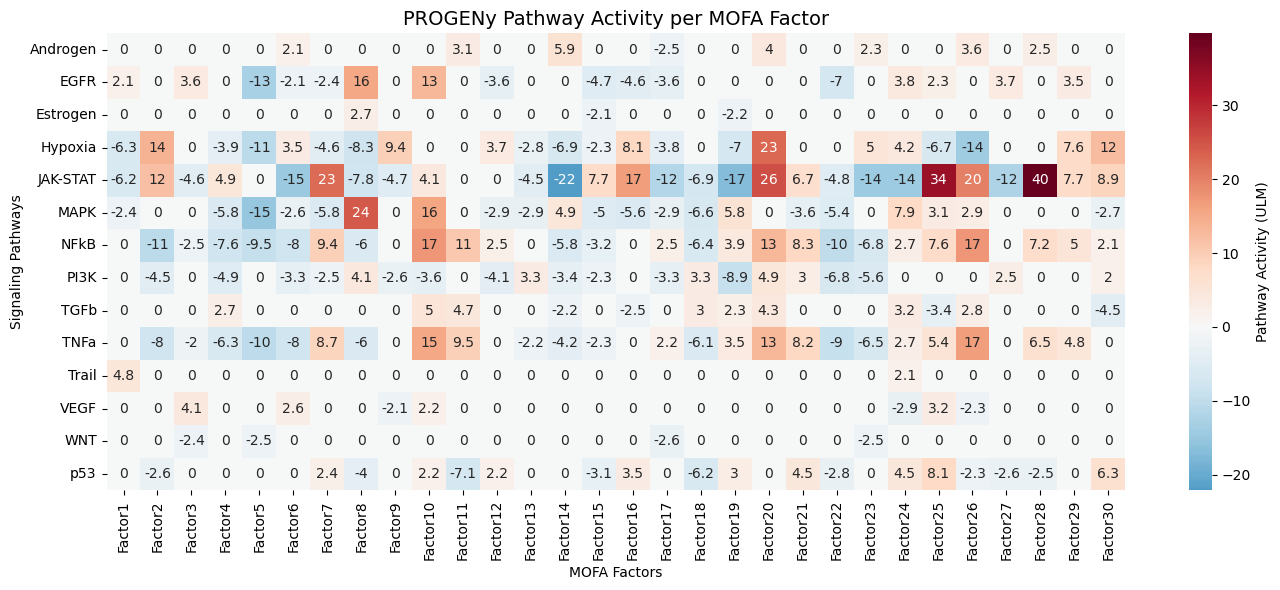

In [6]:
# Heatmap PROGENy
acts_progeny_sig = acts_progeny.copy()
acts_progeny_sig[pvals_progeny > 0.05] = 0

plt.figure(figsize=(14, 6))
sns.heatmap(
    acts_progeny_sig.loc[factor_order].T,
    cmap='RdBu_r', center=0, annot=True,
    yticklabels=True,
    cbar_kws={'label': 'Pathway Activity (ULM)'}
)
plt.title("PROGENy Pathway Activity per MOFA Factor", fontsize=14)
plt.xlabel("MOFA Factors")
plt.ylabel("Signaling Pathways")
plt.tight_layout()
plt.savefig(PATH_OUT_GRAF + 'heatmap_progeny.png', dpi=300)
plt.show()

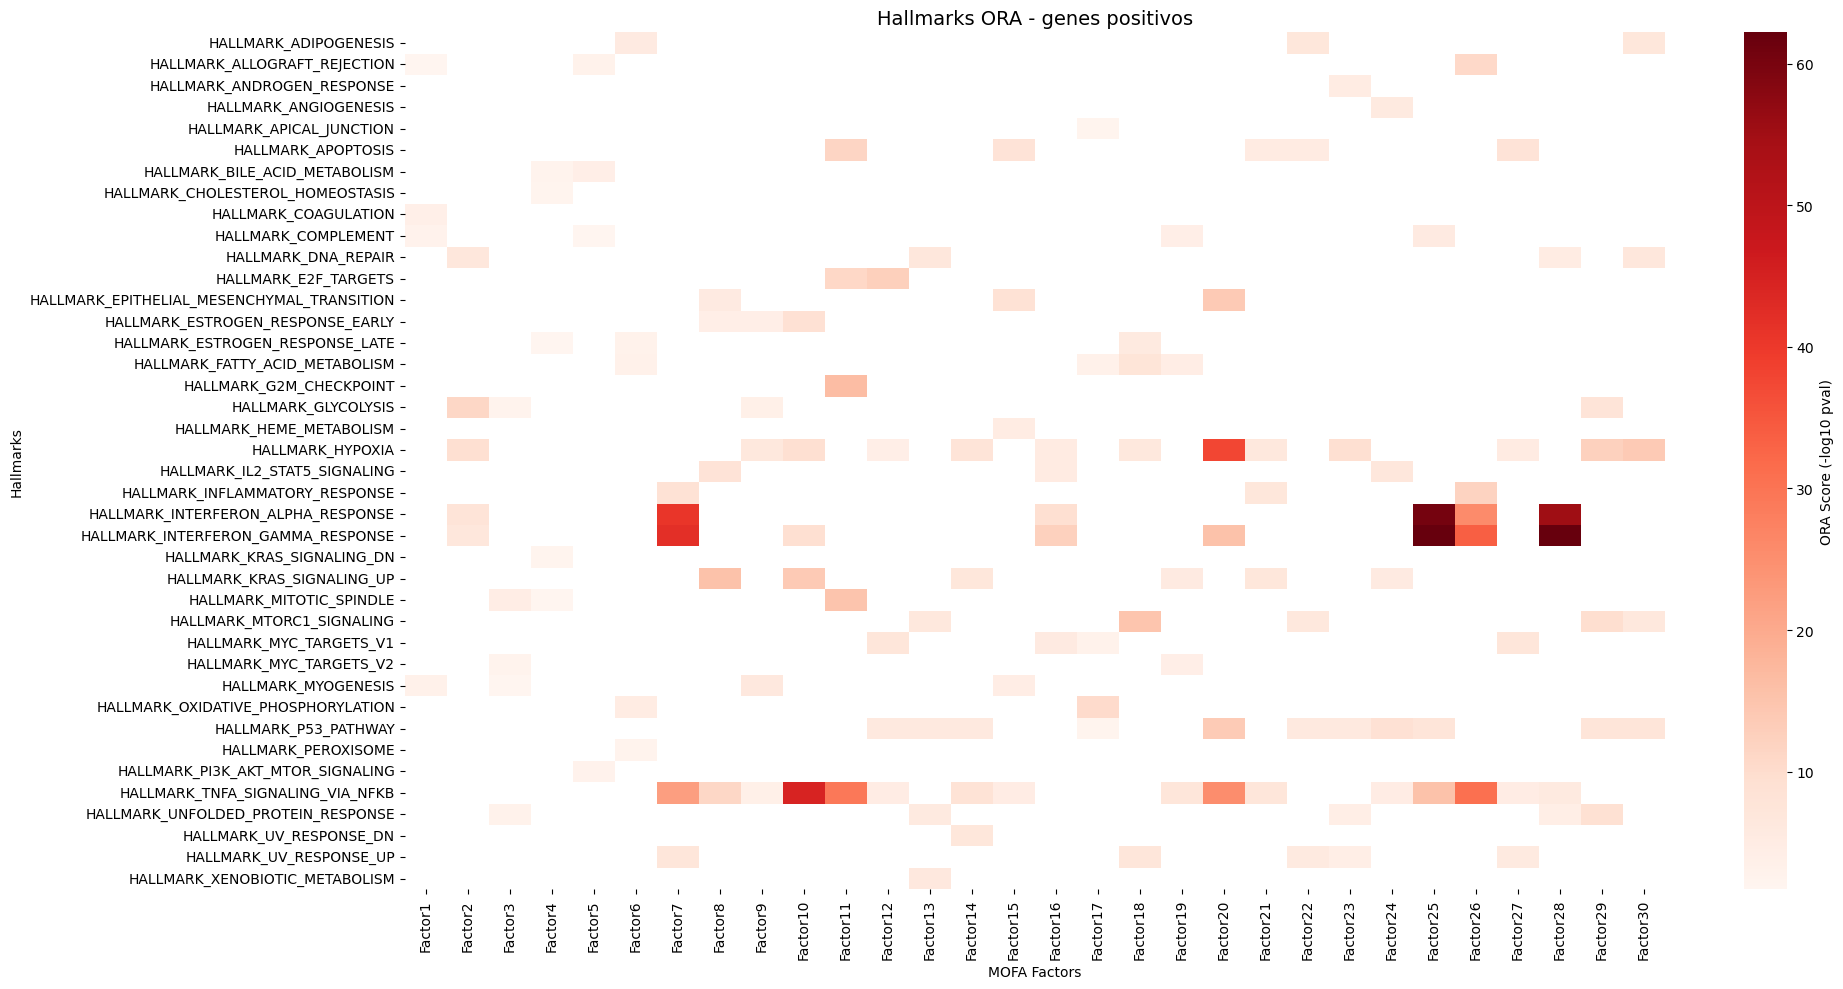

In [7]:
plt.figure(figsize=(20, 10))
sns.heatmap(
    mat_pos_sig.dropna(axis=1, how='all').T,  # .T para hallmarks en Y, factores en X
    cmap='Reds',          # solo positivos, no RdBu_r
    yticklabels=True,
    xticklabels=True,
    cbar_kws={'label': 'ORA Score (-log10 pval)'}  # etiqueta correcta
)
plt.title("Hallmarks ORA - genes positivos", fontsize=14)
plt.xlabel("MOFA Factors")
plt.ylabel("Hallmarks")
plt.tight_layout()
plt.savefig(PATH_OUT_GRAF + 'heatmap_hallmarks_pos.png', dpi=300)
plt.show()

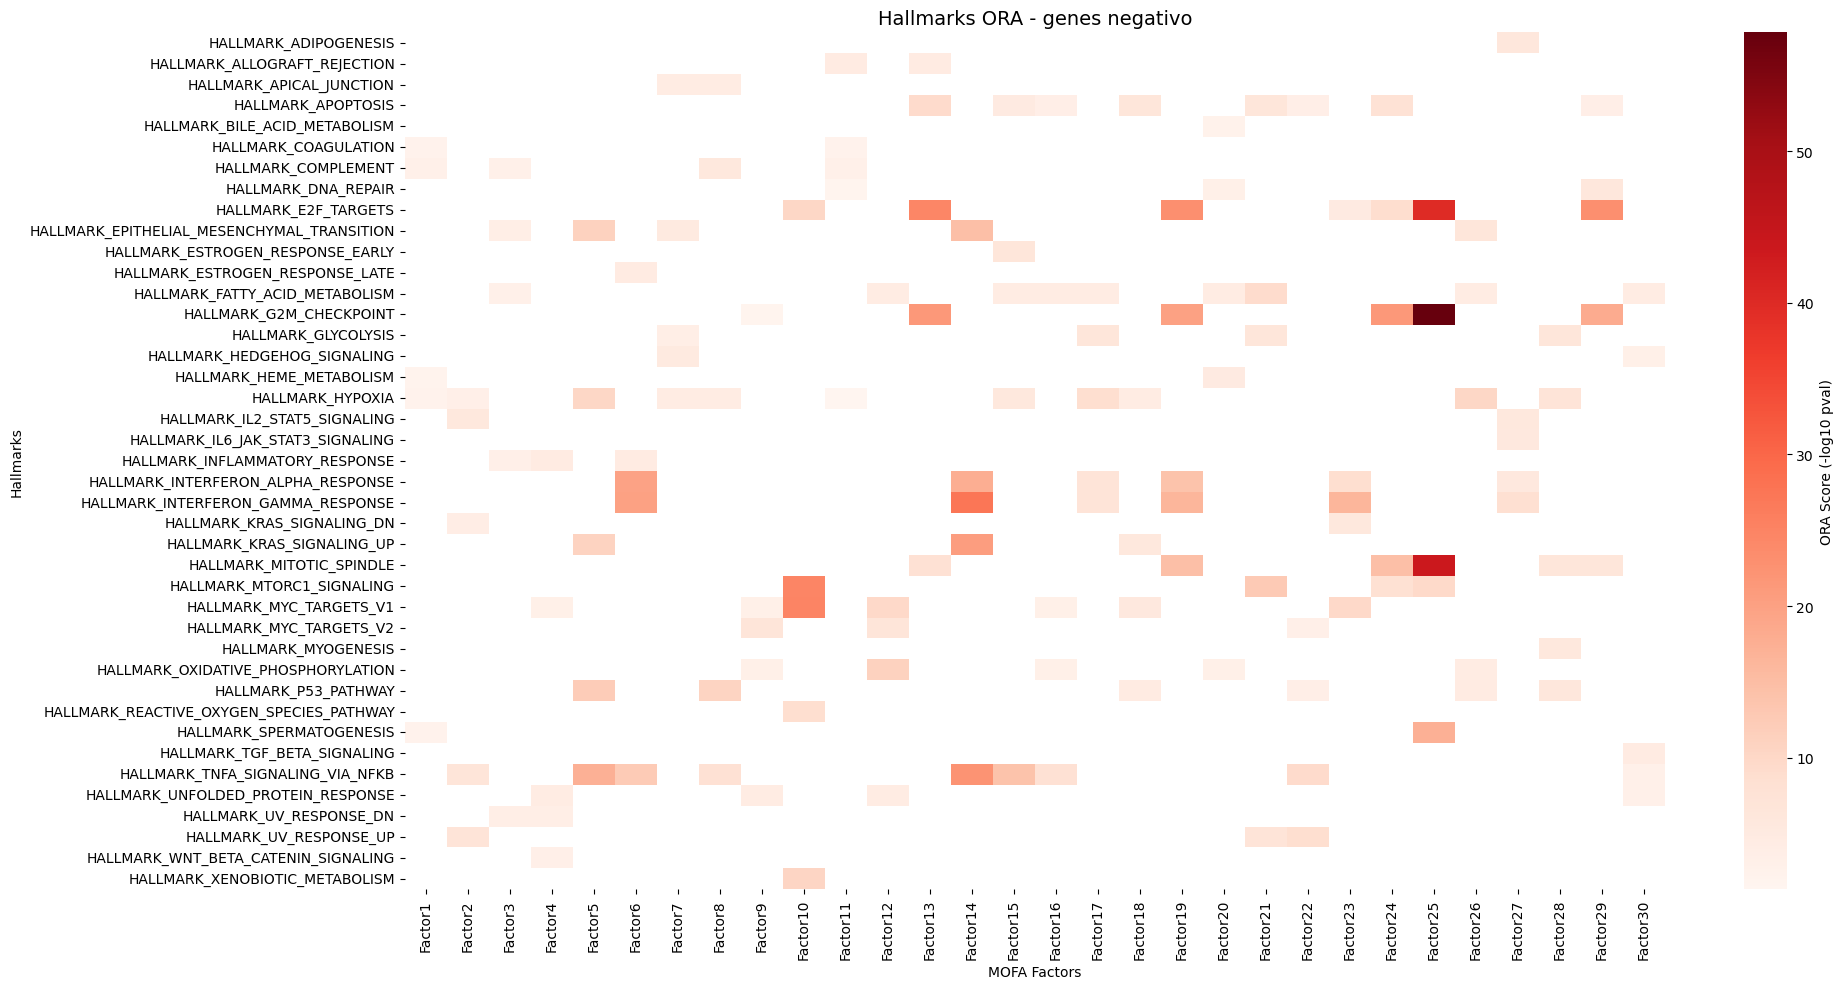

In [8]:
plt.figure(figsize=(20, 10))
sns.heatmap(
    mat_neg_sig.dropna(axis=1, how='all').T,  # .T para hallmarks en Y, factores en X
    cmap='Reds',          # solo positivos, no RdBu_r
    yticklabels=True,
    xticklabels=True,
    cbar_kws={'label': 'ORA Score (-log10 pval)'}  # etiqueta correcta
)
plt.title("Hallmarks ORA - genes negativo", fontsize=14)
plt.xlabel("MOFA Factors")
plt.ylabel("Hallmarks")
plt.tight_layout()
plt.savefig(PATH_OUT_GRAF + 'heatmap_hallmarks_neg.png', dpi=300)
plt.show()

## 5. Varianza Explicada por Factor

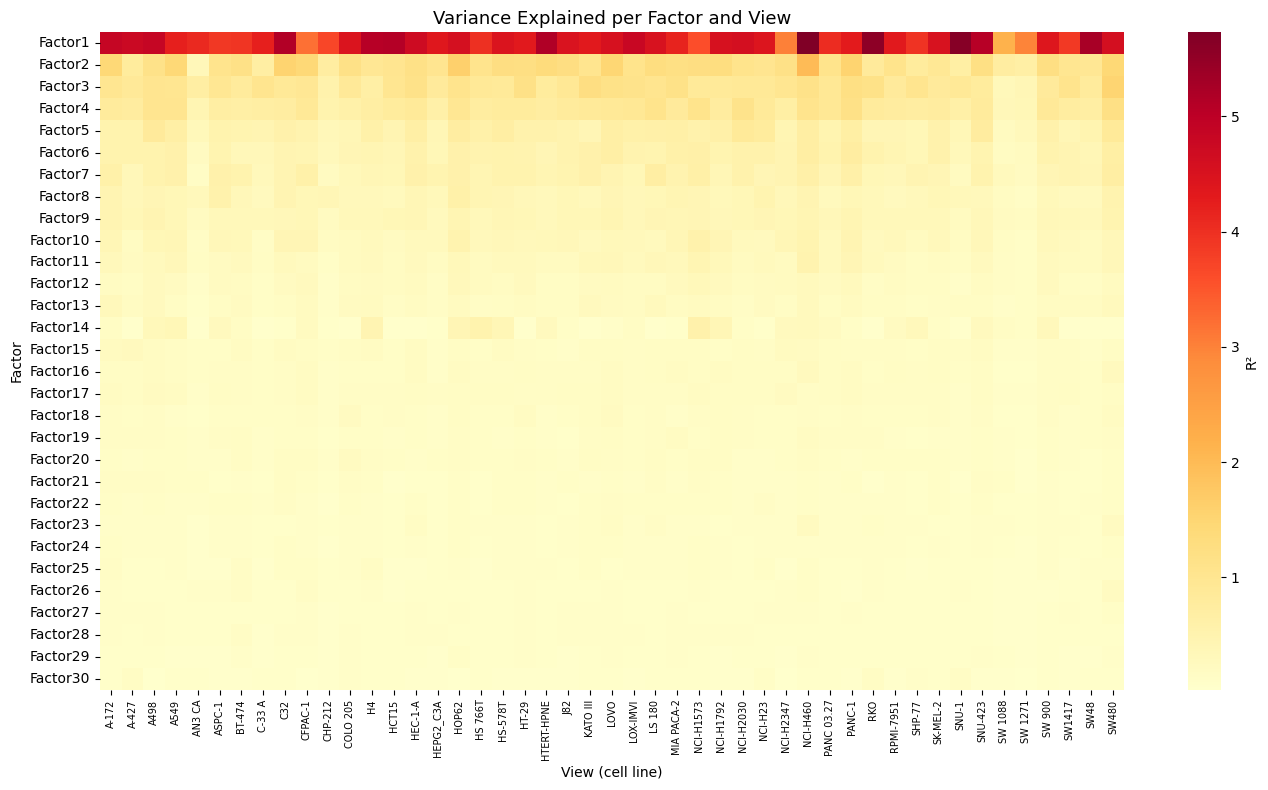

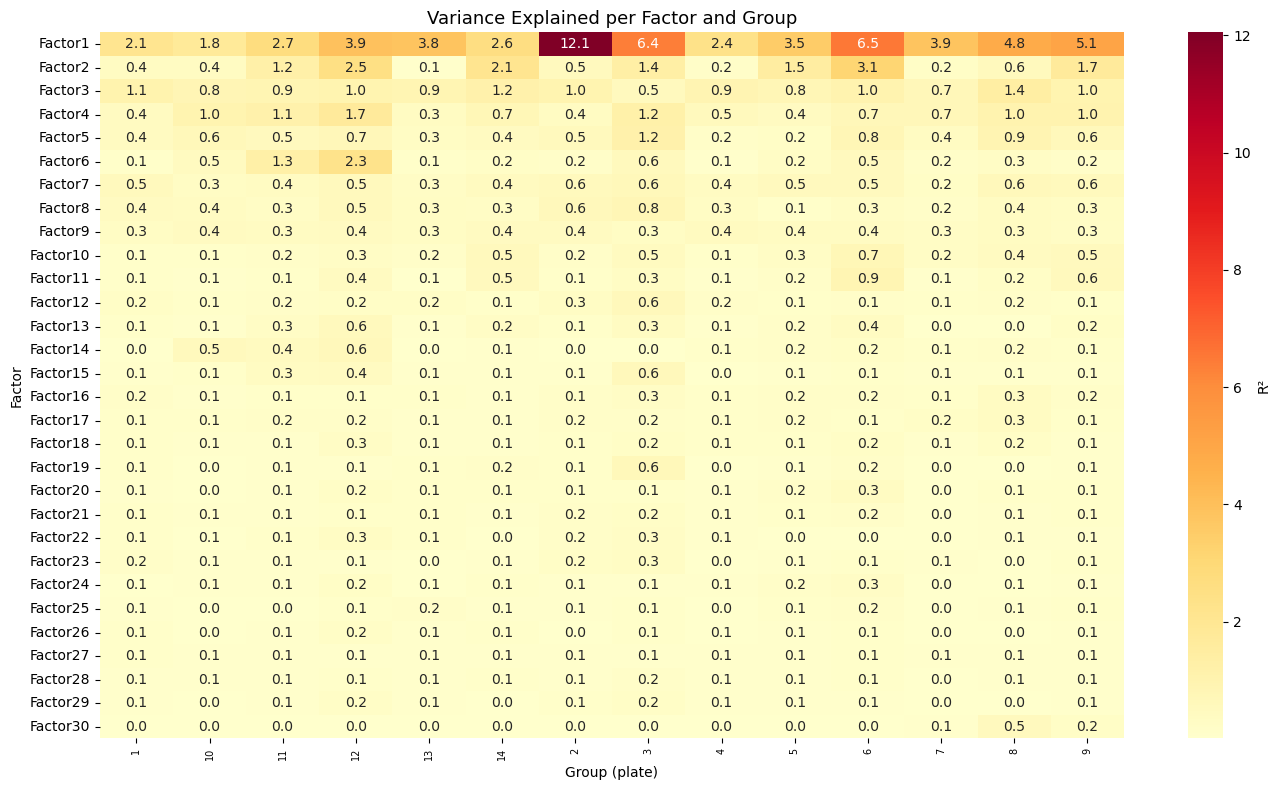

In [9]:
model = mfx.mofa_model(PATH_MODEL)
r2    = model.get_r2()

r2_per_view  = r2.groupby(["Factor", "View"])["R2"].mean().reset_index()
r2_per_group = r2.groupby(["Factor", "Group"])["R2"].mean().reset_index()

r2_view_pivot  = r2_per_view.pivot(index="Factor",  columns="View",  values="R2").loc[factor_order]
r2_group_pivot = r2_per_group.pivot(index="Factor", columns="Group", values="R2").loc[factor_order]

plt.figure(figsize=(14, 8))
sns.heatmap(r2_view_pivot, cmap="YlOrRd",
            yticklabels=True, cbar_kws={"label": "R²"})
plt.title("Variance Explained per Factor and View", fontsize=13)
plt.xlabel("View (cell line)")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig(f"{PATH_OUT_GRAF}_variance_per_view.png", dpi=300, bbox_inches='tight')
plt.show()



plt.figure(figsize=(14,8))
sns.heatmap(r2_group_pivot, cmap="YlOrRd",
            annot=True, fmt=".1f", yticklabels=True, cbar_kws={"label": "R²"})
plt.title("Variance Explained per Factor and Group", fontsize=13)
plt.xlabel("Group (plate)")
plt.xticks(rotation=90, fontsize=7)
plt.savefig(f"{PATH_OUT_GRAF}_variance_per_group.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 6. Tabla Resumen Final por Factor

In [10]:
# --- Cargar ANOVAs con corrección FDR ---
dfs_cov = {}
for cov in ['concentration', 'drug', 'moa_fine', 'plate']:
    df = pd.read_excel(PATH_BATCH + f'anova_{cov}.xlsx')
    _, pvals_fdr, _, _ = multipletests(df['P_Value'], method='fdr_bh')
    df[f'FDR_{cov}'] = pvals_fdr
    df = df.rename(columns={
        'F_Stat':   f'F_stat_{cov}',
        'P_Value':  f'pval_{cov}',
        'Veredicto': f'sig_{cov}'
    })
    dfs_cov[cov] = df

df_covariates = (dfs_cov['concentration']
    .merge(dfs_cov['drug'],     on='Factor')
    .merge(dfs_cov['moa_fine'], on='Factor')
    .merge(dfs_cov['plate'],    on='Factor')
)

# --- Merge final ---
df_final = (df_genes
    .merge(df_resumen_progeny, on='Factor')
    .merge(df_hallmarks_ora,   on='Factor')
    .merge(df_covariates,      on='Factor')
)

print(f"Tabla final: {df_final.shape[0]} factores x {df_final.shape[1]} columnas")

# --- Guardar en Excel con pestañas temáticas ---
out = PATH_OUT + 'resumen_factores_completo.xlsx'

cols_genes    = ['Factor'] + [c for c in df_final.columns if 'Genes' in c]
cols_progeny  = ['Factor'] + [c for c in df_final.columns if 'PROGENy' in c]
cols_hallmark = ['Factor'] + [c for c in df_final.columns if 'Hallmark' in c]
cols_cov      = ['Factor'] + [c for c in df_final.columns if any(x in c for x in ['F_', 'pval_', 'FDR_', 'sig_'])]

with pd.ExcelWriter(out, engine='openpyxl') as writer:
    df_final.to_excel(writer,               sheet_name='Resumen_completo', index=False)
    df_final[cols_genes].to_excel(writer,   sheet_name='Top_Genes',        index=False)
    df_final[cols_progeny].to_excel(writer, sheet_name='PROGENy',          index=False)
    df_final[cols_hallmark].to_excel(writer,sheet_name='Hallmarks',        index=False)
    df_final[cols_cov].to_excel(writer,     sheet_name='Covariates',       index=False)

print(f"Guardado en {out}")

Tabla final: 30 factores x 23 columnas
Guardado en /home/ulc/co/mao/drug_clustering/TFM_mao/resultados/resumen_factores_completo.xlsx


ENRUECIMIENTO DE LOS MOAS

In [11]:
# --- Rutas ---
PATH_ADATA = "/mnt/lustre/scratch/nlsas/home/ulc/co/mao/modelo_prueba_final_fast_convergence/adata/mofa_adata_30f.h5ad"
# --- Cargar datos ---
adata = ad.read_h5ad(PATH_ADATA)

# factores x muestras (usando los factor scores, no los pesos)
factor_scores = pd.DataFrame(
    adata.X,
    index=adata.obs['drug'],
    columns=adata.uns['mofa_weights_factors']
  ).T  # factores x muestras
factor_scores = factor_scores.T.groupby(level='drug').mean().T
net = adata.obs[['moa-fine','drug']].drop_duplicates().reset_index(drop=True)
net['weight'] = 1

acts, pvals = dc.run_ulm(mat=factor_scores, net=net, source='moa-fine', target='drug', weight='weight')
acts_signif = acts.where(pvals < 0.05)

/tmp/ipykernel_2593155/129893554.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  factor_scores = factor_scores.T.groupby(level='drug').mean().T


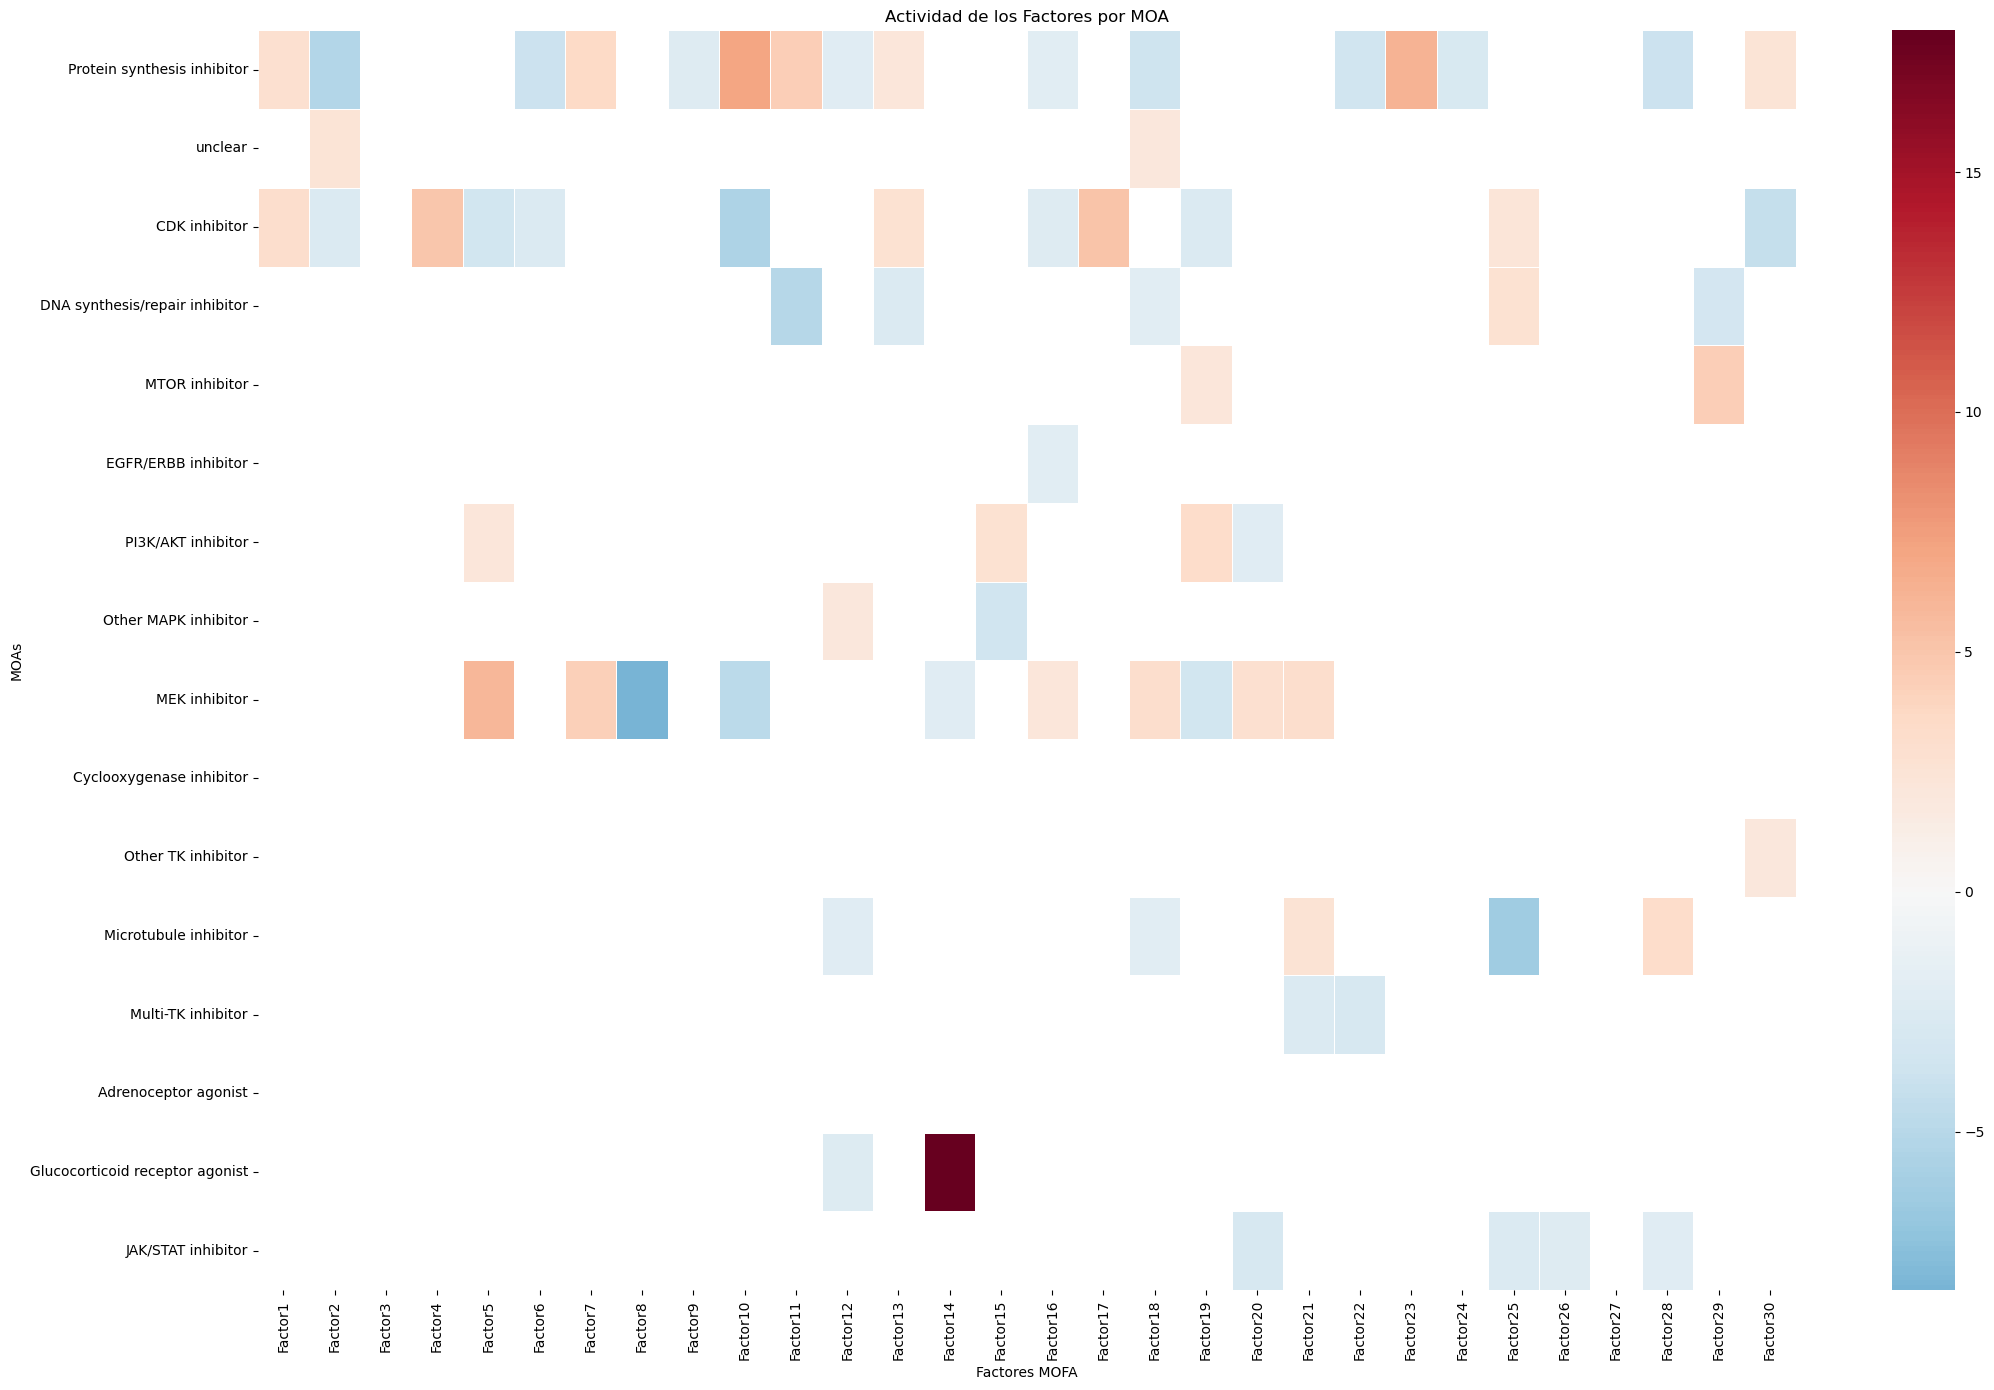

In [12]:
fig, ax = plt.subplots(figsize=(22, 14))
sns.heatmap(acts_signif.T,
            cmap='RdBu_r',
            center=0,
            linewidths=0.5,
            #fmt=".2f",
            #annot=True,
            yticklabels=True,
            xticklabels=True,
            ax=ax)
plt.title('Actividad de los Factores por MOA')
plt.xlabel('Factores MOFA')
plt.ylabel('MOAs')
plt.tight_layout()
plt.savefig(PATH_OUT_GRAF + 'heatmap_moas.png', dpi=300)

plt.show()